<a href="https://colab.research.google.com/github/anvay13/anvay13/blob/main/Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA (EXPLORATORY DATA  ANALYSIS)**

Asking Questions



1.Which product category contributes the most to sales?

2.What is the average sales per order?

3.Which sub-category has the highest and lowest sales?

4.Which state has the highest total sales?

5.Who are the top 5 customers based on total purchases?

6.What is the sales distribution across different regions?

7.Which shipping mode is most commonly used?

8.Is there a significant difference in delivery times across different shipping modes?
























Column Types


*   Numerical :Row ID, Postal Code, Sales, Delivery Time.


*   Categorical :Order ID, Ship Mode, Customer ID, Customer Name, Segment,Country, City, State, Region, Product ID, Category, Sub-Category, Product Name.



# **Data Gathering / Accessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
superm = pd.read_csv('/content/drive/MyDrive/supermarket.csv').copy()
superm.head(9)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040


In [ ]:
# 1.Which product category contributes the most to sales?
category_sales = superm.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


In [ ]:
# 1.Which product category contributes the most to sales?
category_sales = superm.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print('This category contributes the most to sales:', category_sales.index[0])

This category contributes the most to sales: Technology


In [ ]:
# 2.What is the average sales per order?
avg_sales_per_order = superm["Sales"].mean()
print("The average sales per order is:", avg_sales_per_order)

The average sales per order is: 230.7690594591837


In [ ]:
# 3.Which sub-category has the highest and lowest sales?
sub_category_sales = superm.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
sub_category_sales

,Sales
Sub-Category,
Phones,327782.4480
Chairs,322822.7310
Storage,219343.3920
Tables,202810.6280
Binders,200028.7850
Machines,189238.6310
Accessories,164186.7000
Copiers,146248.0940
Bookcases,113813.1987


In [ ]:
# 3.Which sub-category has the highest and lowest sales?
subcategory_sales = superm.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
highest_subcategory = subcategory_sales.idxmax()
lowest_subcategory = subcategory_sales.idxmin()
print("The subcategory with the highest sales is:", highest_subcategory)
print("The subcategory with the lowest sales is:", lowest_subcategory)

The subcategory with the highest sales is: Phones
The subcategory with the lowest sales is: Fasteners


In [ ]:
# 4.Which state has the highest total sales?
state_sales = superm.groupby("State")["Sales"].sum().sort_values(ascending=False).idxmax()
print("The state with the highest total sales is:", state_sales)

The state with the highest total sales is: California


In [ ]:
# 4.Which state has the highest total sales?
state_sales = superm.groupby("State")["Sales"].sum().sort_values(ascending=False)
state_sales

,Sales
State,
California,446306.4635
New York,306361.1470
Texas,168572.5322
Washington,135206.8500
Pennsylvania,116276.6500
Florida,88436.5320
Illinois,79236.5170
Michigan,76136.0740
Ohio,75130.3500


In [ ]:
# 5.Who are the top 5 customers based on total purchases?
top_customers = superm.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5)
top_customers

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571


In [ ]:
# 6.What is the sales distribution across different regions?
region_sales = superm.groupby("Region")["Sales"].sum()
region_sales

,Sales
Region,
Central,492646.9132
East,669518.7260
South,389151.4590
West,710219.6845


In [ ]:
# 7.Which shipping mode is most commonly used?
shipping_mode_sales = superm.groupby("Ship Mode")["Sales"].sum().idxmax()
print("The most commonly used shipping mode is:", shipping_mode_sales)

The most commonly used shipping mode is: Standard Class


In [ ]:
# 7.Which shipping mode is most commonly used?
shipping_mode_sales = superm.groupby("Ship Mode")["Sales"].sum()
shipping_mode_sales

,Sales
Ship Mode,
First Class,3.455723e+05
Same Day,1.252190e+05
Second Class,4.499142e+05
Standard Class,1.340831e+06


In [ ]:
superm["Order Date"] = pd.to_datetime(superm["Order Date"], format="%d/%m/%Y", errors='coerce')
superm["Ship Date"] = pd.to_datetime(superm["Ship Date"], format="%d/%m/%Y", errors='coerce')
superm["Delivery Time"] = (superm["Ship Date"] - superm["Order Date"]).dt.days

In [ ]:
# 8.Is there a significant difference in delivery times across different shipping modes?
delivery_time = superm.groupby("Ship Mode")["Delivery Time"].mean()
delivery_time

,Delivery Time
Ship Mode,
First Class,2.179214
Same Day,0.044610
Second Class,3.249211
Standard Class,5.008363


In [ ]:
superm.to_csv("superm.csv", index=False)

# **Cleaning Process**

In [ ]:
# Checking for missing values
missing_values = superm.isnull().sum()
missing_values

0

In [ ]:
# Filling missing postal codes with 0
superm["Postal Code"] = superm["Postal Code"].fillna(0)
superm.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# Removing duplicate entries
superm = superm.drop_duplicates()
superm

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Delivery Time
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,7
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,5
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880,5
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,5


# **Univariate Analysis**

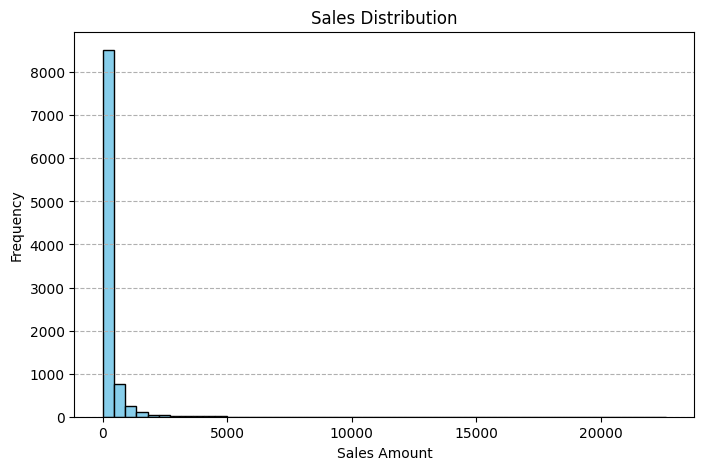

In [ ]:
# Plot 1: Sales Distribution
plt.figure(figsize=(8, 5))
plt.hist(superm["Sales"], bins=50, color="skyblue", edgecolor="black")
plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=1.0)

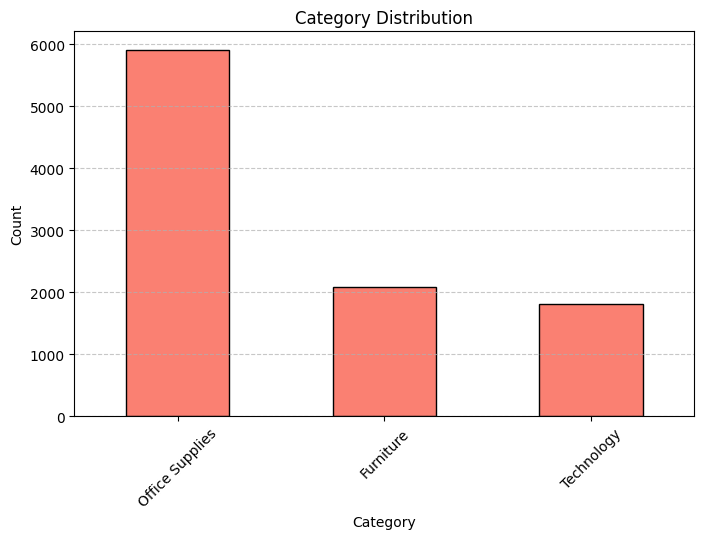

In [ ]:
# Plot 2: Category Count
plt.figure(figsize=(8, 5))
superm["Category"].value_counts().plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

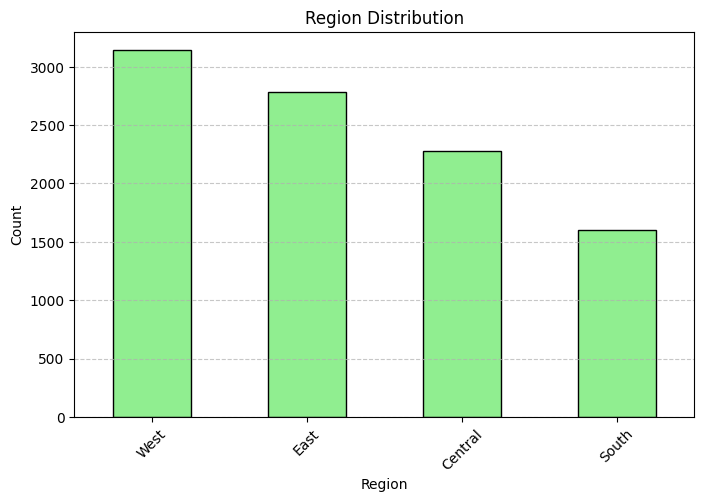

In [ ]:
# Plot 3: Region Count
plt.figure(figsize=(8, 5))
superm["Region"].value_counts().plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Region Distribution")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

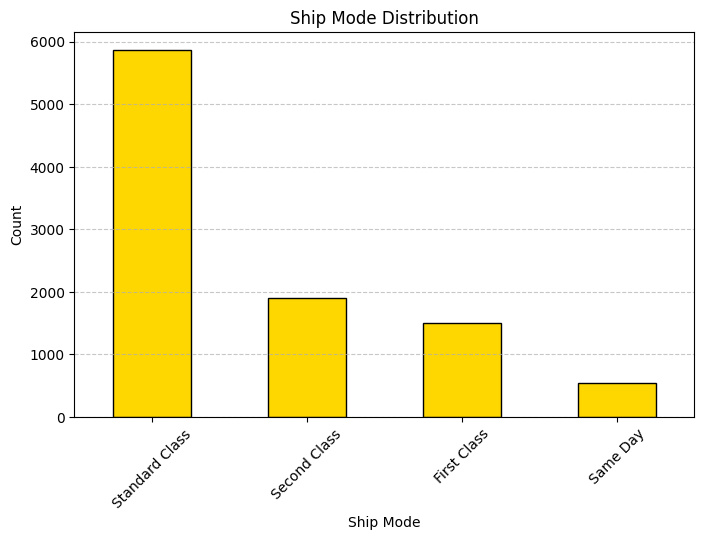

In [ ]:
# Plot 4: Ship Mode Count
plt.figure(figsize=(8, 5))
superm["Ship Mode"].value_counts().plot(kind="bar", color="gold", edgecolor="black")
plt.title("Ship Mode Distribution")
plt.xlabel("Ship Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

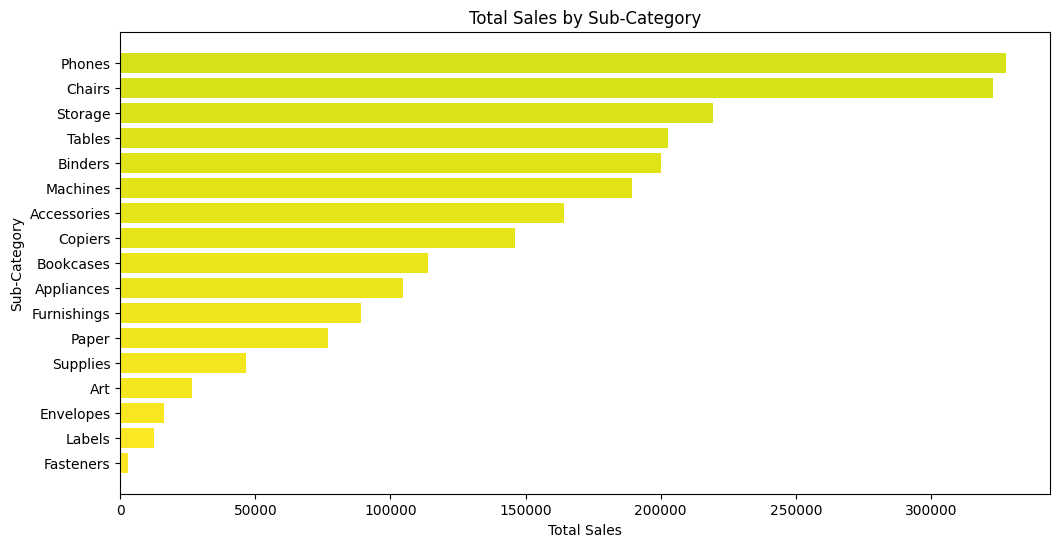

In [ ]:
# Bar Plot: Total Sales by Sub-Category

# Grouping sales by sub-category
subcategory_sales = superm.groupby("Sub-Category")["Sales"].sum().sort_values()

# Generating unique colors for each bar
colors = plt.cm.viridis_r(range(len(subcategory_sales)))

plt.figure(figsize=(12, 6))
plt.barh(subcategory_sales.index, subcategory_sales.values, color=colors)
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.title("Total Sales by Sub-Category")
plt.show()

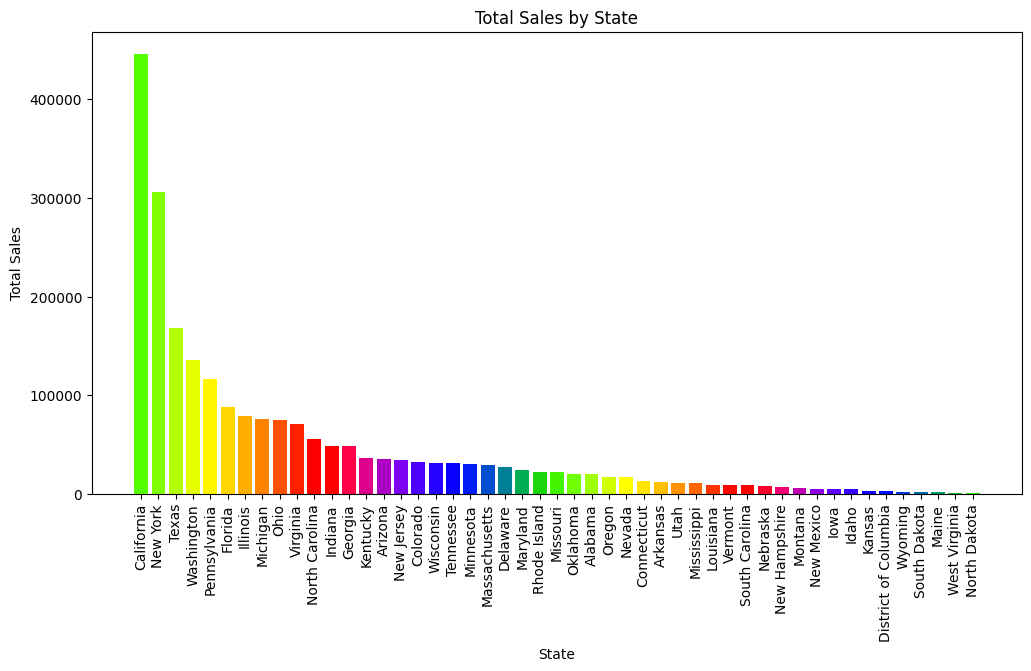

In [ ]:
# Aggregating total sales by state
state_sales = superm.groupby("State")["Sales"].sum().sort_values(ascending=False)

# Defining colors (using a colormap for better visualization)
colors = plt.cm.prism_r(range(len(state_sales)))

# Creating the bar plot
plt.figure(figsize=(12, 6))
plt.bar(state_sales.index, state_sales.values, color=colors)
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.title("Total Sales by State")
plt.xticks(rotation=90)  # Rotating x-axis labels for readability
plt.show()

# **Bivariate Analysis**

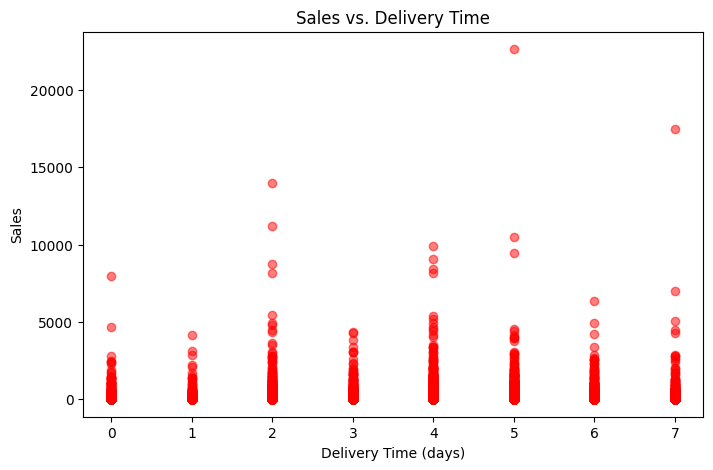

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(superm["Delivery Time"], superm["Sales"], alpha=0.5, color='red')
plt.xlabel("Delivery Time (days)")
plt.ylabel("Sales")
plt.title("Sales vs. Delivery Time")
plt.show()

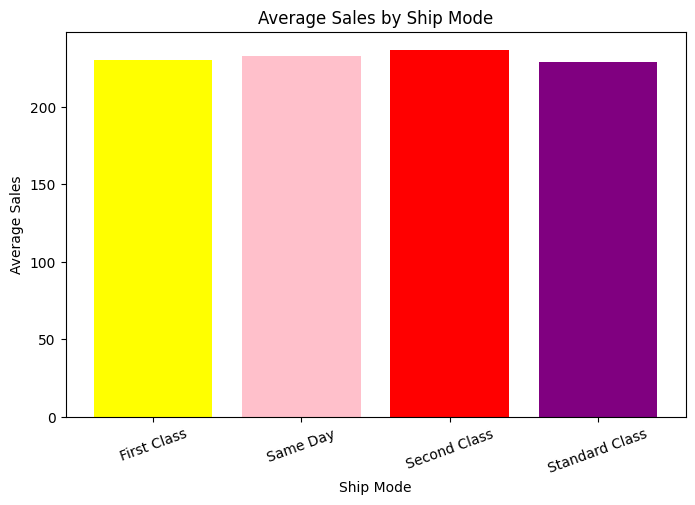

In [ ]:
# Bar Plot: Average Sales by Ship Mode
colors = ['yellow', 'pink', 'red', 'purple'] # Define colors for each bar
avg_sales_ship_mode = superm.groupby("Ship Mode")["Sales"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_sales_ship_mode.index, avg_sales_ship_mode.values, color=colors)
plt.xlabel("Ship Mode")
plt.ylabel("Average Sales")
plt.title("Average Sales by Ship Mode")
plt.xticks(rotation=20)
plt.show()

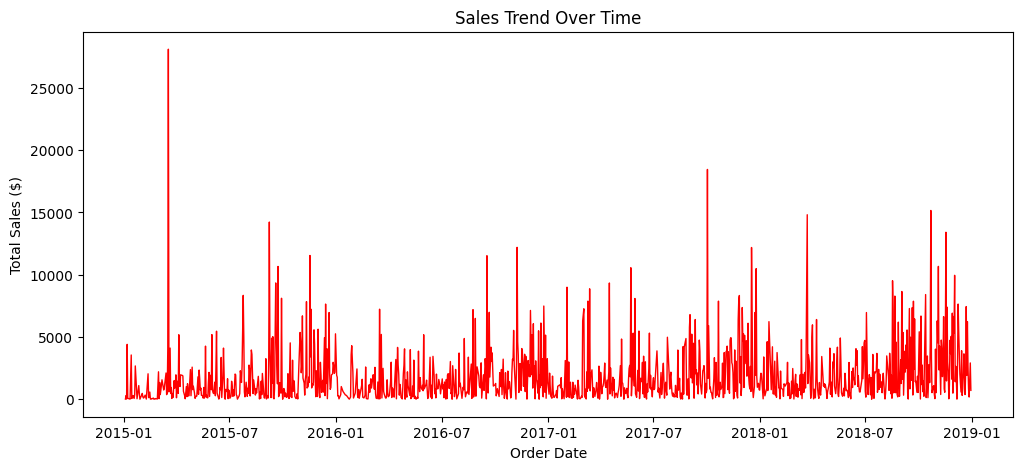

In [ ]:
# Line Plot: Sales Trend Over Time
superm["Order Date"] = pd.to_datetime(superm["Order Date"], errors='coerce')
sales_trend = superm.groupby("Order Date")["Sales"].sum()

plt.figure(figsize=(12, 5))
plt.plot(sales_trend.index, sales_trend.values, color='red', linestyle='-', linewidth=1)
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.title("Sales Trend Over Time")
plt.show()

Text(0.5, 0.98, '')

<Figure size 1000x600 with 0 Axes>

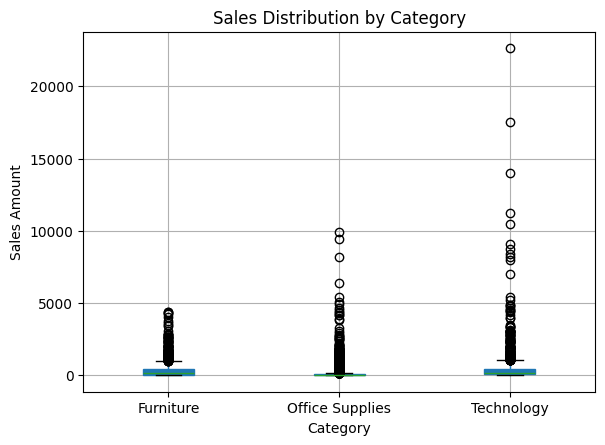

In [ ]:
# Plot 1: Sales vs. Category (Box Plot)
plt.figure(figsize=(10, 6))
superm.boxplot(column="Sales", by="Category", patch_artist=True)
plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.suptitle("")  # Remove automatic title

Text(0.5, 0.98, '')

<Figure size 1000x600 with 0 Axes>

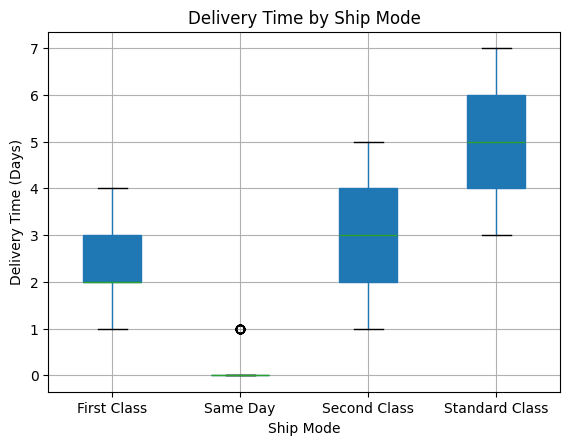

In [ ]:
# Plot 2: Delivery Time vs. Ship Mode (Box Plot)
plt.figure(figsize=(10, 6))
superm.boxplot(column="Delivery Time", by="Ship Mode", patch_artist=True)
plt.title("Delivery Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Delivery Time (Days)")
plt.suptitle("")  # Remove automatic title